## 8.5 경제물리학에서의 양자 터널링

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from scipy.constants import hbar, m_e, e
from scipy.optimize import curve_fit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 상수
m = m_e  # 전자 질량
V0 = 1.0 * e  # 퍼텐셜 장벽 (eV)
a = 1e-10  # 장벽 너비 (m)
E = np.linspace(0.01 * e, 2 * e, 500)  # 에너지 범위 (J)

In [3]:
# 양자 터널링 투과 확률
def transmission_probability(E, m, V0, a):
    k2 = np.sqrt(2 * m * (V0 - E)) / hbar
    T = np.exp(-2 * k2 * a)
    T[E >= V0] = 0  # 장벽 높이보다 큰 에너지에서는 NaN 방지
    return T

In [4]:
# 투과 확률 계산
T = transmission_probability(E, m, V0, a)

In [5]:
# 유효하지 않은 값 제거
valid_idx = np.isfinite(T) & (T > 0)
E_valid = E[valid_idx]
T_valid = T[valid_idx]

In [6]:
# 경제물리학 시나리오 모사 (가설 함수)
def market_behavior(E, a, b):
    return a * np.exp(-b * E)

In [7]:
# 투과 확률에 모델 적합
popt, _ = curve_fit(market_behavior, E_valid / e, T_valid)
predicted_T = market_behavior(E_valid / e, *popt)

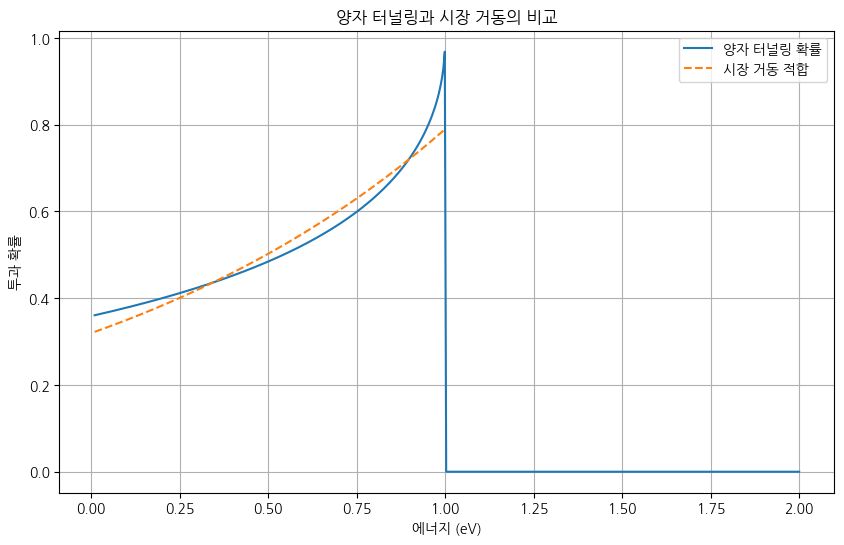

In [8]:
# 비교 그리기
plt.figure(figsize=(10, 6))
plt.plot(E / e, T, label='양자 터널링 확률')
plt.plot(E_valid / e, predicted_T, label='시장 거동 적합', linestyle='--')
plt.title('양자 터널링과 시장 거동의 비교')
plt.xlabel('에너지 (eV)')
plt.ylabel('투과 확률')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
# Qiskit 통합: 양자회로 시뮬레이션
qc = QuantumCircuit(1)
qc.h(0)  # 하다마드 게이트로 중첩 생성
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q"), index=0>,), clbits=())

In [10]:
# 터널링 효과를 표현하는 사용자 게이트 추가
theta = np.arcsin(np.sqrt(predicted_T[0]))  # 첫 적합 투과 확률 사용
qc.ry(2 * theta, 0)

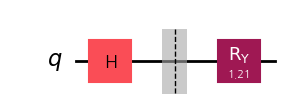

In [11]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [12]:
 # 측정
qc.measure_all()

In [13]:
# AerSimulator 초기화
simulator = AerSimulator()

In [14]:
# 상태벡터 저장
qc.save_statevector()

In [15]:
# 회로 실행
result = simulator.run(qc).result()
counts = result.get_counts()
statevector = result.get_statevector(qc)

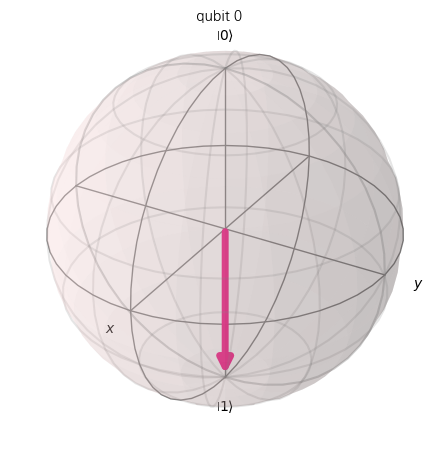

In [16]:
# 결과를 블로흐 구로 시각화
plot_bloch_multivector(statevector).show()

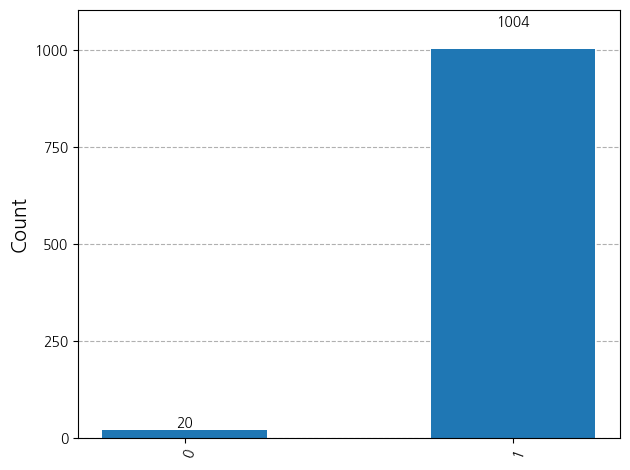

In [17]:
# 측정 결과를 히스토그램으로 시각화
plot_histogram(counts).show()